# V2: Model Creation
## 4.1 Loading Files

In [1]:
import pandas as pd

train_v2_numericalized = pd.read_parquet('data/processed/train_v2_numericalized.parquet')
validation_v2_numericalized = pd.read_parquet('data/processed/validation_v2_numericalized.parquet')

print(f'Train Shape: {train_v2_numericalized.shape}')
print(f'Validation Shape:{validation_v2_numericalized.shape}')

assert 'tokens_ids' in train_v2_numericalized.columns
assert 'tokens_ids' in validation_v2_numericalized

for index in [1, 10, 200]:
    sequence = train_v2_numericalized['tokens_ids'].iloc[index]
    print(f'Sequence of tokens turned into ids: {sequence}')
    print(f'Number of tokens: {len(sequence)}\n')

print(f'Train Columns: {train_v2_numericalized.columns.tolist()}')
print(f'Validation Columns: {validation_v2_numericalized.columns.tolist()}')

Train Shape: (22809, 4)
Validation Shape:(5703, 4)
Sequence of tokens turned into ids: [248 249 337 161 388 258 662 154 592 161 588 154 155 155 247 249 337 161
 388 258 662 154 592 161 588 154 155 164 850 154 155 155]
Number of tokens: 32

Sequence of tokens turned into ids: [247 249 525 154 155]
Number of tokens: 5

Sequence of tokens turned into ids: [247 249 760 154 367 155]
Number of tokens: 6

Train Columns: ['diff', 'top_level_label', 'tokens', 'tokens_ids']
Validation Columns: ['diff', 'top_level_label', 'tokens', 'tokens_ids']


## 4.2 Label to ID

In [2]:
train_unique_labels = train_v2_numericalized['top_level_label'].unique()
validation_unique_labels = validation_v2_numericalized['top_level_label'].unique()
assert not set(validation_unique_labels).difference(set(train_unique_labels))

label_to_ids = {label: label_id for label_id, label in enumerate(sorted(train_unique_labels))}

In [3]:
train_v2_numericalized['label_id'] = train_v2_numericalized['top_level_label'].map(label_to_ids)
assert not train_v2_numericalized['label_id'].isnull().any()

validation_v2_numericalized['label_id'] = validation_v2_numericalized['top_level_label'].map(label_to_ids)
assert not validation_v2_numericalized['label_id'].isnull().any()


for index in [1, 20, 1000]:
    label = train_v2_numericalized['top_level_label'].loc[index]
    label_id = train_v2_numericalized['label_id'].loc[index]
    print(f'Index: {index} Label: {label}\nLabel ID: {label_id}')

Index: 1 Label: call
Label ID: 1
Index: 20 Label: control_flow
Label ID: 2
Index: 1000 Label: expression
Label ID: 3


## 4.3 Saving the Label to Id

In [4]:
import json
train_v2_numericalized.to_parquet('data/processed/train_v2_label_id.parquet', index=False)
validation_v2_numericalized.to_parquet('data/processed/validation_v2_label_id.parquet', index=False)

ids_to_labels = {ident: label for label, ident in label_to_ids.items()}
print(ids_to_labels)

with open('data/processed/label_to_id.json', 'w') as file:
    json.dump(label_to_ids, file)

with open('data/processed/id_to_label.json', 'w') as file:
    json.dump(ids_to_labels, file)


{0: 'assignment', 1: 'call', 2: 'control_flow', 3: 'expression', 4: 'identifier'}


## 4.4 Creating the Train and Validation Dataset

In [5]:
from src.v2.data import BugFixDataset

train_dataset = BugFixDataset(train_v2_numericalized)
validation_dataset = BugFixDataset(validation_v2_numericalized)

In [6]:
tokens, label = train_dataset[0]
print(tokens)
print(tokens.dtype, tokens.shape)
print(label)
print(label.dtype, label.shape)

tensor([248, 249, 542, 576, 161, 603, 583, 521, 154, 602, 164, 745, 154, 771,
        161, 211, 155, 155, 242, 247, 249, 542, 576, 161, 603, 583, 521, 154,
        602, 164, 745, 154, 771, 155, 155, 242])
torch.int64 torch.Size([36])
tensor(1)
torch.int64 torch.Size([])


## 4.5 Validating Model Related Functions

In [7]:
for index in [0, 10, 200]: #at random indices
    train_tokens, train_label_id = train_dataset[index]
    assert train_tokens.numel() == len(train_v2_numericalized['tokens_ids'].iloc[index]) #ensuring the number of elements in the tensor is the same number of tokens
    assert train_label_id.item() == train_v2_numericalized['label_id'].iloc[index] #matching ids

    validation_tokens, validation_label_id = validation_dataset[index] #checking the same for the validation set
    assert validation_tokens.numel() == len(validation_v2_numericalized['tokens_ids'].iloc[index])
    assert validation_label_id.item() == validation_v2_numericalized['label_id'].iloc[index]

assert len(train_dataset) == len(train_v2_numericalized) #ensuring that the datasets have matching rows
assert len(validation_dataset) == len(validation_v2_numericalized)

In [8]:
from src.v2.data import collate_batch
import torch

test_batch = [train_dataset[0], train_dataset[10], train_dataset[200]] #choose rows
tokens, labels, mask = collate_batch(test_batch)

for row_index, (original_tokens, _) in enumerate(test_batch):
    original_length = len(original_tokens)

    assert torch.equal(tokens[row_index, :original_length], original_tokens) #first argument is row and second is columns
    assert (tokens[row_index, original_length:] == 0).all()

## 4.6 Using DataLoader and Validating Shapes 

In [9]:
from torch.utils.data import DataLoader
from src.v2.data import collate_batch

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, collate_fn=collate_batch) #returns an iterable a batch that has an iterable of (tokens, labels, mask)
validation_loader = DataLoader(validation_dataset, batch_size=32, shuffle=False, collate_fn=collate_batch)

train_tokens, train_labels, train_mask = next(iter(train_loader))
validation_tokens, validation_labels, validation_mask = next(iter(validation_loader))

assert train_tokens.shape == train_mask.shape
assert validation_tokens.shape == validation_mask.shape

assert train_tokens.shape[0] == train_labels.shape[0]
assert validation_tokens.shape[0] == validation_labels.shape[0]

assert train_tokens.dtype == torch.long
assert validation_tokens.dtype == torch.long

assert train_labels.dtype == torch.long
assert validation_labels.dtype == torch.long

assert train_mask.dtype == torch.bool
assert validation_mask.dtype == torch.bool

print(f'Train Tokens Shape: {train_tokens.shape}')
print(f'Train Labels Shape: {train_labels.shape}')
print(f'Train Mask Shape: {train_mask.shape}')

print(f'Validation Token Shape:{validation_tokens.shape}')
print(f'Validation Labels Shape: {validation_labels.shape}')
print(f'Validation Mask Shape: {validation_mask.shape}')

Train Tokens Shape: torch.Size([32, 80])
Train Labels Shape: torch.Size([32])
Train Mask Shape: torch.Size([32, 80])
Validation Token Shape:torch.Size([32, 76])
Validation Labels Shape: torch.Size([32])
Validation Mask Shape: torch.Size([32, 76])


## 4.7 Training the Model:

In [10]:
from src.v2.train import train_model, BugFixClassifier
import torch.nn as nn
torch.manual_seed(42)

with open('data/processed/token_to_id.json', 'r') as f:
    token_to_id = json.load(f)

with open('data/processed/label_to_id.json', 'r') as f:
    label_to_id = json.load(f)
model = BugFixClassifier(vocab_size=len(token_to_id), embedding_dimension=128, num_classes=len(label_to_id), padding_index=token_to_id['<PAD>'])
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

history = train_model(model, train_loader, validation_loader, criterion, optimizer, 15)

Epoch: 1, Train Loss: 0.7844, Train Accuracy: 0.6835 Validation Loss: 0.6197 Validation Accuracy: 0.7326
Epoch: 2, Train Loss: 0.6025, Train Accuracy: 0.7366 Validation Loss: 0.5769 Validation Accuracy: 0.7438
Epoch: 3, Train Loss: 0.5693, Train Accuracy: 0.7499 Validation Loss: 0.5580 Validation Accuracy: 0.7563
Epoch: 4, Train Loss: 0.5509, Train Accuracy: 0.7605 Validation Loss: 0.5467 Validation Accuracy: 0.7598
Epoch: 5, Train Loss: 0.5381, Train Accuracy: 0.7667 Validation Loss: 0.5411 Validation Accuracy: 0.7594
Epoch: 6, Train Loss: 0.5280, Train Accuracy: 0.7725 Validation Loss: 0.5363 Validation Accuracy: 0.7652
Epoch: 7, Train Loss: 0.5202, Train Accuracy: 0.7799 Validation Loss: 0.5321 Validation Accuracy: 0.7708
Epoch: 8, Train Loss: 0.5135, Train Accuracy: 0.7814 Validation Loss: 0.5317 Validation Accuracy: 0.7749
Epoch: 9, Train Loss: 0.5080, Train Accuracy: 0.7840 Validation Loss: 0.5304 Validation Accuracy: 0.7749
Epoch: 10, Train Loss: 0.5027, Train Accuracy: 0.7867 V

## 4.8 Plotting the Epoch Curve

Most of the improvements occurred during the earlier epochs. After approximately epoch 8, the validation loss began to level off while the training loss continued decreasing. This suggests mild overfitting and diminishing returns from additional training. I selected the checkpoint from epoch 13 because it had the lowest validation loss of 0.5284.

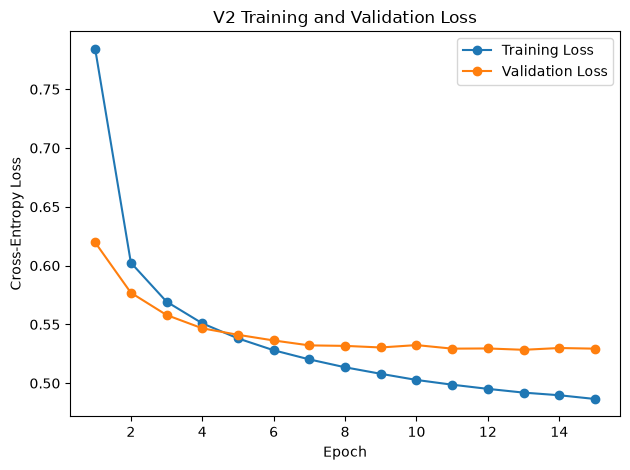

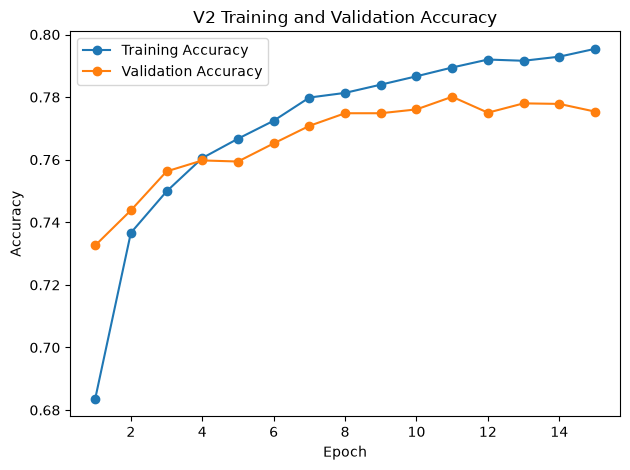

In [11]:
import matplotlib.pyplot as plt

epoch_numbers = range(1, len(history['train_loss']) + 1)

plt.plot(epoch_numbers, history['train_loss'], marker='o', label='Training Loss')
plt.plot(epoch_numbers, history['validation_loss'], marker='o', label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.title('V2 Training and Validation Loss')
plt.legend()
plt.tight_layout()
plt.show()

plt.plot(epoch_numbers, history['train_accuracy'], marker='o', label='Training Accuracy')
plt.plot(epoch_numbers, history['validation_accuracy'], marker='o', label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('V2 Training and Validation Accuracy')
plt.legend()
plt.tight_layout()
plt.show()